# CALF BTCUSDT pred_len=16 artifact visualization

This notebook visualizes CALF evaluation artifacts created by `Exp_Long_Term_Forecast.test(test=1)`.

It does not run model inference. It only reads saved artifacts:

```text
CALF/results/<setting>/eval_YYYYMMDD_HHMMSS_itr0/
  pred_0.npy
  true_0.npy
  metrics_0.npy
  run_info.txt
```

Important: plots stay in the exact evaluation/artifact space used by the author. The notebook does **not** inverse-transform to raw price. CALF's model applies instance normalization internally and returns `outputs_time` back to the dataloader-scaled space; `metrics_0.npy` is computed directly on these saved scaled arrays. Keeping this space avoids visual mismatch with the reported MSE/MAE.

Before plotting, it rebuilds CALF's test dataloader and validates that each artifact's `true_0.npy` matches the dataloader `batch_y[:, -pred_len:, :]` order used by the author. This prevents plotting predictions against misaligned ground truth.

In [28]:
%matplotlib inline

from __future__ import annotations

from argparse import Namespace
from pathlib import Path
import ast
import os
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

## Locate CALF and set evaluation constants

In [29]:
def find_calf_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == "CALF" and (candidate / "run.py").exists() and (candidate / "data_provider").is_dir():
            return candidate
        calf = candidate / "CALF"
        if (calf / "run.py").exists() and (calf / "data_provider").is_dir():
            return calf.resolve()
    raise RuntimeError("Cannot locate CALF root from the current working directory.")

CALF_ROOT = find_calf_root()
os.chdir(CALF_ROOT)
if str(CALF_ROOT) not in sys.path:
    sys.path.insert(0, str(CALF_ROOT))

DATA_ROOT = CALF_ROOT / "dataset" / "clean"
DATA_FILE = "BTCUSDT_15m_calf.csv"
RESULTS_ROOT = CALF_ROOT / "results"
TARGET = "close"
TARGET_INDEX = -1
BATCH_SIZE = 128
EXPECTED_PRED_LEN = 16
VARIANT_ORDER = ["ori", "dropAttn_keepWE", "llm_to_attn", "llm_to_trsf"]

print("CALF_ROOT:", CALF_ROOT)
print("DATA:", DATA_ROOT / DATA_FILE)
print("RESULTS_ROOT:", RESULTS_ROOT)

CALF_ROOT: C:\Users\USER\Desktop\time_series\LLM for timeseries\LLMsForTimeSeries\CALF
DATA: C:\Users\USER\Desktop\time_series\LLM for timeseries\LLMsForTimeSeries\CALF\dataset\clean\BTCUSDT_15m_calf.csv
RESULTS_ROOT: C:\Users\USER\Desktop\time_series\LLM for timeseries\LLMsForTimeSeries\CALF\results


## Discover evaluation artifacts

The `setting` folder name is parsed with the same fields used by `run.py`. The run subfolder is kept so repeated evaluations do not overwrite or get mixed.

In [30]:
SETTING_RE = re.compile(
    r"^long_term_forecast_"
    r"(?P<model_id>.+?)_"
    r"(?P<model>GPT4TS)_"
    r"(?P<data>custom)_"
    r"ft(?P<features>[A-Z]+)_"
    r"sl(?P<seq_len>\d+)_"
    r"ll(?P<label_len>\d+)_"
    r"pl(?P<pred_len>\d+)_"
    r"dm(?P<d_model>\d+)_"
    r"nh(?P<n_heads>\d+)_"
    r"el(?P<e_layers>\d+)_"
    r"dl(?P<d_layers>\d+)_"
    r"df(?P<d_ff>\d+)_"
    r"fc(?P<factor>\d+)_"
    r"eb(?P<embed>[^_]+)_"
    r"dt(?P<distil>True|False)_"
    r"(?P<des>[^_]+)_"
    r"gpt(?P<gpt_layers>\d+)_"
    r"(?P<setting_itr>\d+)$"
)

INT_FIELDS = {"seq_len", "label_len", "pred_len", "d_model", "n_heads", "e_layers", "d_layers", "d_ff", "factor", "gpt_layers", "setting_itr"}


def parse_setting(setting: str) -> dict:
    match = SETTING_RE.match(setting)
    if not match:
        raise ValueError(f"Cannot parse CALF setting name: {setting}")
    meta = match.groupdict()
    for key in INT_FIELDS:
        meta[key] = int(meta[key])
    return meta


def parse_variant(model_id: str) -> str:
    for variant in VARIANT_ORDER:
        if model_id.endswith("_" + variant) or model_id == variant or variant in model_id:
            return variant
    return "unknown"


def parse_run_info(path: Path) -> dict:
    if not path.exists():
        return {}
    info = {}
    for line in path.read_text(encoding="utf-8").splitlines():
        if ": " not in line:
            continue
        key, value = line.split(": ", 1)
        if key.endswith("shape"):
            try:
                value = ast.literal_eval(value)
            except Exception:
                pass
        elif key in {"seq_len", "pred_len", "ii"}:
            try:
                value = int(value)
            except ValueError:
                pass
        elif key in {"mse", "mae"}:
            try:
                value = float(value)
            except ValueError:
                pass
        info[key] = value
    return info


def parse_artifact_itr(path: Path) -> int:
    match = re.match(r"pred_(\d+)\.npy$", path.name)
    if not match:
        raise ValueError(f"Unexpected prediction filename: {path.name}")
    return int(match.group(1))


def load_shape(path: Path) -> tuple[int, ...]:
    return tuple(np.load(path, mmap_mode="r", allow_pickle=False).shape)


def discover_artifacts(results_root: Path = RESULTS_ROOT) -> pd.DataFrame:
    rows = []
    if not results_root.exists():
        return pd.DataFrame(rows)

    for pred_path in sorted(results_root.rglob("pred_*.npy")):
        run_dir = pred_path.parent
        setting_dir = run_dir.parent if run_dir.name.startswith("eval_") else run_dir
        setting = setting_dir.name
        setting_meta = parse_setting(setting)
        artifact_itr = parse_artifact_itr(pred_path)
        true_path = run_dir / f"true_{artifact_itr}.npy"
        metrics_path = run_dir / f"metrics_{artifact_itr}.npy"
        run_info_path = run_dir / "run_info.txt"
        if not true_path.exists():
            raise FileNotFoundError(f"Missing matching true file for {pred_path}: {true_path}")

        run_info = parse_run_info(run_info_path)
        pred_shape = load_shape(pred_path)
        true_shape = load_shape(true_path)
        if pred_shape != true_shape:
            raise ValueError(f"Shape mismatch for {run_dir}: pred={pred_shape}, true={true_shape}")

        model_id = run_info.get("model_id", setting_meta["model_id"])
        rows.append({
            **setting_meta,
            "variant": parse_variant(model_id),
            "artifact_itr": artifact_itr,
            "run_name": run_dir.name,
            "run_dir": run_dir,
            "pred_path": pred_path,
            "true_path": true_path,
            "metrics_path": metrics_path if metrics_path.exists() else None,
            "run_info_path": run_info_path if run_info_path.exists() else None,
            "pred_shape": pred_shape,
            "true_shape": true_shape,
            "run_info_mae": run_info.get("mae"),
            "run_info_mse": run_info.get("mse"),
            "mtime": pred_path.stat().st_mtime,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df = df.sort_values(["pred_len", "variant", "mtime"], ascending=[True, True, False]).reset_index(drop=True)
    return df

artifacts = discover_artifacts()
if artifacts.empty:
    raise FileNotFoundError(f"No pred_*.npy artifacts found under {RESULTS_ROOT}")

summary_cols = ["variant", "model_id", "pred_len", "seq_len", "artifact_itr", "run_name", "pred_shape", "run_info_mae", "run_info_mse", "run_dir"]
display(artifacts[summary_cols])

,variant,model_id,pred_len,seq_len,artifact_itr,run_name,pred_shape,run_info_mae,run_info_mse,run_dir
0,dropAttn_keepWE,BTCUSDT_96_16_dropAttn_keepWE,16,96,0,eval_20260529_061020_itr0,"(13952, 16, 7)",0.169939,0.262389,C:\Users\USER\Desktop\time_series\LLM for time...
1,llm_to_attn,BTCUSDT_96_16_llm_to_attn,16,96,0,eval_20260529_061044_itr0,"(13952, 16, 7)",0.170279,0.266996,C:\Users\USER\Desktop\time_series\LLM for time...
2,llm_to_trsf,BTCUSDT_96_16_llm_to_trsf,16,96,0,eval_20260529_061106_itr0,"(13952, 16, 7)",0.171636,0.269421,C:\Users\USER\Desktop\time_series\LLM for time...
3,ori,BTCUSDT_96_16_ori,16,96,0,eval_20260529_060958_itr0,"(13952, 16, 7)",0.168834,0.267050,C:\Users\USER\Desktop\time_series\LLM for time...


## Rebuild CALF test windows and validate alignment

CALF's long-term `test()` uses:

- `data_provider(args, "test")`
- `shuffle=False`
- `drop_last=True`
- `batch_y[:, -pred_len:, :]`

The validation below reconstructs those arrays and checks every artifact's `true_0.npy` against the dataloader target. If this fails, plotting is stopped.

In [31]:
def feature_columns_for_custom_csv(csv_path: Path, target: str) -> list[str]:
    df = pd.read_csv(csv_path, nrows=1)
    cols = list(df.columns)
    cols.remove(target)
    cols.remove("date")
    return cols + [target]

FEATURE_COLUMNS = feature_columns_for_custom_csv(DATA_ROOT / DATA_FILE, TARGET)
if FEATURE_COLUMNS[TARGET_INDEX] != TARGET:
    raise RuntimeError(f"Expected target at index {TARGET_INDEX}, got {FEATURE_COLUMNS[TARGET_INDEX]}")
print("feature columns:", FEATURE_COLUMNS)


def make_data_args(row: pd.Series) -> Namespace:
    return Namespace(
        task_name="long_term_forecast",
        data=row.data,
        root_path=str(DATA_ROOT) + os.sep,
        data_path=DATA_FILE,
        model_id=row.model_id,
        seq_len=int(row.seq_len),
        label_len=int(row.label_len),
        pred_len=int(row.pred_len),
        features=row.features,
        target=TARGET,
        embed=row.embed,
        freq="15min",
        seasonal_patterns="Monthly",
        percent=100,
        batch_size=BATCH_SIZE,
        num_workers=0,
    )


def build_test_dates(seq_len: int, pred_len: int) -> pd.Series:
    df_raw = pd.read_csv(DATA_ROOT / DATA_FILE)
    cols = list(df_raw.columns)
    cols.remove(TARGET)
    cols.remove("date")
    df_raw = df_raw[["date"] + cols + [TARGET]]
    num_test = int(len(df_raw) * 0.2)
    border1 = len(df_raw) - num_test - seq_len
    border2 = len(df_raw)
    dates = pd.to_datetime(df_raw["date"].iloc[border1:border2]).reset_index(drop=True)
    expected_windows = len(dates) - seq_len - pred_len + 1
    if expected_windows <= 0:
        raise RuntimeError(f"Invalid test date length: dates={len(dates)}, seq_len={seq_len}, pred_len={pred_len}")
    return dates


def collect_author_test_arrays(row: pd.Series) -> dict:
    from data_provider.data_factory import data_provider

    args = make_data_args(row)
    test_data, test_loader = data_provider(args, "test")
    contexts = []
    trues = []
    for batch_x, batch_y, batch_x_mark, batch_y_mark in test_loader:
        batch_x = batch_x.float()
        batch_y = batch_y.float()
        contexts.append(batch_x[:, -args.seq_len:, :].numpy())
        trues.append(batch_y[:, -args.pred_len:, :].numpy())
    if not contexts:
        raise RuntimeError("CALF test loader produced no batches")
    contexts = np.concatenate(contexts, axis=0)
    trues = np.concatenate(trues, axis=0)
    dates = build_test_dates(args.seq_len, args.pred_len)
    kept_windows = (len(test_data) // args.batch_size) * args.batch_size
    if len(contexts) != kept_windows:
        raise RuntimeError(f"Unexpected kept window count: contexts={len(contexts)}, kept={kept_windows}, dataset={len(test_data)}")
    return {"args": args, "dataset": test_data, "context_scaled": contexts, "true_scaled": trues, "dates": dates}

base_row = artifacts[(artifacts.pred_len == EXPECTED_PRED_LEN)].iloc[0]
author_data = collect_author_test_arrays(base_row)
print("author context:", author_data["context_scaled"].shape)
print("author true:", author_data["true_scaled"].shape)
print("test date range:", author_data["dates"].iloc[0], "->", author_data["dates"].iloc[-1])

feature columns: ['open', 'high', 'low', 'volume', 'quote_volume', 'number_of_trades', 'close']
percent 100
test 14020
author context: (13952, 96, 7)
author true: (13952, 16, 7)
test date range: 2025-08-06 19:30:00 -> 2026-01-01 00:00:00


## Load and validate every artifact

Validation checks:

1. prediction and ground-truth arrays are both `[N, pred_len, features]`
2. `true_0.npy` exactly matches CALF dataloader targets after the author's `.float()` cast
3. saved metrics match recomputed scaled MAE/MSE

In [32]:
def load_artifact_arrays(row: pd.Series) -> tuple[np.ndarray, np.ndarray, np.ndarray | None]:
    pred = np.load(Path(row.pred_path), allow_pickle=False)
    true = np.load(Path(row.true_path), allow_pickle=False)
    metrics = None
    if row.metrics_path is not None:
        metrics = np.load(Path(row.metrics_path), allow_pickle=False)
    return pred, true, metrics


def validate_artifact(row: pd.Series, author: dict, atol: float = 1e-6) -> dict:
    pred, true, metrics = load_artifact_arrays(row)
    if pred.ndim != 3 or true.ndim != 3:
        raise ValueError(f"Expected 3D arrays for {row.run_dir}, got pred={pred.shape}, true={true.shape}")
    if pred.shape != true.shape:
        raise ValueError(f"Prediction and true shapes differ for {row.run_dir}: pred={pred.shape}, true={true.shape}")
    if pred.shape[1] != int(row.pred_len):
        raise ValueError(f"Artifact pred_len mismatch for {row.run_dir}: shape={pred.shape}, metadata={row.pred_len}")
    if pred.shape[2] != len(FEATURE_COLUMNS):
        raise ValueError(f"Feature count mismatch for {row.run_dir}: shape={pred.shape}, features={len(FEATURE_COLUMNS)}")
    if pred.shape[0] != author["true_scaled"].shape[0]:
        raise ValueError(f"Window count mismatch for {row.run_dir}: artifact={pred.shape[0]}, dataloader={author['true_scaled'].shape[0]}")

    true_diff = float(np.max(np.abs(true - author["true_scaled"])))
    if true_diff > atol:
        raise ValueError(f"Ground-truth alignment failed for {row.run_dir}: max_abs_diff={true_diff}")

    mae = float(np.mean(np.abs(pred - true)))
    mse = float(np.mean((pred - true) ** 2))
    metric_mae_diff = None
    metric_mse_diff = None
    if metrics is not None:
        metric_mae_diff = float(abs(metrics[0] - mae))
        metric_mse_diff = float(abs(metrics[1] - mse))
        if metric_mae_diff > 1e-5 or metric_mse_diff > 1e-5:
            raise ValueError(
                f"Metric mismatch for {row.run_dir}: saved=({metrics[0]}, {metrics[1]}), recomputed=({mae}, {mse})"
            )

    return {
        "row_index": int(row.name),
        "variant": row.variant,
        "run_name": row.run_name,
        "pred_shape": pred.shape,
        "true_max_abs_diff_vs_loader": true_diff,
        "scaled_mae": mae,
        "scaled_mse": mse,
        "metric_mae_diff": metric_mae_diff,
        "metric_mse_diff": metric_mse_diff,
    }

validation_rows = [validate_artifact(row, author_data) for _, row in artifacts.iterrows()]
validation = pd.DataFrame(validation_rows)
display(validation)

,row_index,variant,run_name,pred_shape,true_max_abs_diff_vs_loader,scaled_mae,scaled_mse,metric_mae_diff,metric_mse_diff
0,0,dropAttn_keepWE,eval_20260529_061020_itr0,"(13952, 16, 7)",0.0,0.169939,0.262389,0.0,0.0
1,1,llm_to_attn,eval_20260529_061044_itr0,"(13952, 16, 7)",0.0,0.170279,0.266996,0.0,0.0
2,2,llm_to_trsf,eval_20260529_061106_itr0,"(13952, 16, 7)",0.0,0.171636,0.269421,0.0,0.0
3,3,ori,eval_20260529_060958_itr0,"(13952, 16, 7)",0.0,0.168834,0.267050,0.0,0.0


## Select latest run per variant

By default, comparison uses the newest artifact for each variant. You can change `SELECTED_ROW_INDICES` manually if you want older runs.

In [33]:
def latest_per_variant(df: pd.DataFrame, pred_len: int = EXPECTED_PRED_LEN) -> pd.DataFrame:
    selected = df[df.pred_len == pred_len].sort_values("mtime").groupby("variant", as_index=False).tail(1)
    order = {variant: idx for idx, variant in enumerate(VARIANT_ORDER)}
    selected = selected.assign(_order=selected.variant.map(order).fillna(999).astype(int))
    return selected.sort_values("_order").drop(columns="_order").reset_index(drop=True)

selected_artifacts = latest_per_variant(artifacts)
SELECTED_ROW_INDICES = selected_artifacts.index.tolist()
display(selected_artifacts[["variant", "model_id", "run_name", "pred_shape", "run_dir"]])

,variant,model_id,run_name,pred_shape,run_dir
0,ori,BTCUSDT_96_16_ori,eval_20260529_060958_itr0,"(13952, 16, 7)",C:\Users\USER\Desktop\time_series\LLM for time...
1,dropAttn_keepWE,BTCUSDT_96_16_dropAttn_keepWE,eval_20260529_061020_itr0,"(13952, 16, 7)",C:\Users\USER\Desktop\time_series\LLM for time...
2,llm_to_attn,BTCUSDT_96_16_llm_to_attn,eval_20260529_061044_itr0,"(13952, 16, 7)",C:\Users\USER\Desktop\time_series\LLM for time...
3,llm_to_trsf,BTCUSDT_96_16_llm_to_trsf,eval_20260529_061106_itr0,"(13952, 16, 7)",C:\Users\USER\Desktop\time_series\LLM for time...


## Prepare values in CALF evaluation space

No inverse transform is applied. `context_values`, `true_values`, and every forecast are kept exactly in the scaled space saved by CALF evaluation. This is the same space used by `metric(preds, trues)` in `Exp_Long_Term_Forecast.test()`.

In [34]:
context_values = author_data["context_scaled"]
true_values = author_data["true_scaled"]


def artifact_pred_values(row: pd.Series) -> np.ndarray:
    pred, true, metrics = load_artifact_arrays(row)
    return pred

print("context eval space:", context_values.shape)
print("true eval space:", true_values.shape)
print("target feature:", FEATURE_COLUMNS[TARGET_INDEX])

context eval space: (13952, 96, 7)
true eval space: (13952, 16, 7)
target feature: close


## Diagnostics: persistence baseline and feature-level error

A flat forecast can still get low aggregate MSE on a short-horizon financial series, especially when the target behaves close to a random walk. This table compares each selected artifact with a persistence baseline that repeats the last context value for all 16 future steps.

In [35]:
persistence_values = np.repeat(context_values[:, -1:, :], EXPECTED_PRED_LEN, axis=1)


def summarize_against_persistence(row: pd.Series) -> dict:
    pred = artifact_pred_values(row)
    true = true_values
    close_idx = TARGET_INDEX
    pred_close = pred[:, :, close_idx]
    true_close = true[:, :, close_idx]
    pers_close = persistence_values[:, :, close_idx]
    last_close = context_values[:, -1:, close_idx]
    return {
        "variant": row.variant,
        "saved_mae_all": float(np.load(Path(row.metrics_path), allow_pickle=False)[0]) if row.metrics_path is not None else np.nan,
        "saved_mse_all": float(np.load(Path(row.metrics_path), allow_pickle=False)[1]) if row.metrics_path is not None else np.nan,
        "close_mae": float(np.mean(np.abs(pred_close - true_close))),
        "persistence_close_mae": float(np.mean(np.abs(pers_close - true_close))),
        "close_mae_vs_persistence_%": float((np.mean(np.abs(pred_close - true_close)) / np.mean(np.abs(pers_close - true_close)) - 1.0) * 100.0),
        "pred_delta_abs_mean": float(np.mean(np.abs(pred_close - last_close))),
        "true_delta_abs_mean": float(np.mean(np.abs(true_close - last_close))),
        "pred_step_abs_mean": float(np.mean(np.abs(np.diff(pred_close, axis=1)))),
        "true_step_abs_mean": float(np.mean(np.abs(np.diff(true_close, axis=1)))),
        "direction_acc_first_step": float(np.mean(np.sign(pred_close[:, 0] - last_close[:, 0]) == np.sign(true_close[:, 0] - last_close[:, 0]))),
    }


def feature_error_table() -> pd.DataFrame:
    rows = []
    true = true_values
    for _, row in selected_artifacts.iterrows():
        pred = artifact_pred_values(row)
        for feature_idx, feature_name in enumerate(FEATURE_COLUMNS):
            mae = float(np.mean(np.abs(pred[:, :, feature_idx] - true[:, :, feature_idx])))
            persistence_mae = float(np.mean(np.abs(persistence_values[:, :, feature_idx] - true[:, :, feature_idx])))
            rows.append({
                "variant": row.variant,
                "feature": feature_name,
                "mae": mae,
                "persistence_mae": persistence_mae,
                "mae_vs_persistence_%": float((mae / persistence_mae - 1.0) * 100.0) if persistence_mae else np.nan,
            })
    return pd.DataFrame(rows)

diagnostic_summary = pd.DataFrame([summarize_against_persistence(row) for _, row in selected_artifacts.iterrows()])
display(diagnostic_summary)

feature_errors = feature_error_table()
display(feature_errors.pivot(index="feature", columns="variant", values="mae_vs_persistence_%"))

,variant,saved_mae_all,saved_mse_all,close_mae,persistence_close_mae,close_mae_vs_persistence_%,pred_delta_abs_mean,true_delta_abs_mean,pred_step_abs_mean,true_step_abs_mean,direction_acc_first_step
0,ori,0.168834,0.267050,0.028175,0.023059,22.183943,0.015618,0.023059,0.002199,0.008343,0.511826
1,dropAttn_keepWE,0.169939,0.262389,0.025953,0.023059,12.550247,0.011550,0.023059,0.003040,0.008343,0.522864
2,llm_to_attn,0.170279,0.266996,0.026581,0.023059,15.271723,0.012551,0.023059,0.004324,0.008343,0.516198
3,llm_to_trsf,0.171636,0.269421,0.028461,0.023059,23.424709,0.016009,0.023059,0.004615,0.008343,0.509819


variant,dropAttn_keepWE,llm_to_attn,llm_to_trsf,ori
feature,,,,
close,12.550250,15.271722,23.424708,22.183945
high,12.879212,15.313039,24.583532,23.137374
low,13.088505,16.049234,23.330597,22.367512
number_of_trades,-23.276657,-22.329444,-21.541356,-22.966736
open,10.975590,13.868393,22.481790,21.712735
quote_volume,-22.647279,-23.389320,-23.770425,-24.997278
volume,-22.540395,-23.267957,-23.612498,-24.874616


## Choose representative windows

The earlier version selected the worst `ori` window by default, which is useful for debugging but misleading as a first visual. The notebook now defines several windows and uses the median-error window as the default plot:

- `WINDOW_INDEX_MEDIAN`: typical case
- `WINDOW_INDEX_P90`: high-error case
- `WINDOW_INDEX_WORST`: worst case

Change `WINDOW_INDEX` manually if you want to inspect a different regime.

In [36]:
def selected_baseline_row() -> pd.Series:
    baseline = selected_artifacts[selected_artifacts.variant == "ori"]
    if not baseline.empty:
        return baseline.iloc[0]
    return selected_artifacts.iloc[0]

baseline_row = selected_baseline_row()
baseline_pred_values = artifact_pred_values(baseline_row)
close_abs_error = np.mean(np.abs(baseline_pred_values[:, :, TARGET_INDEX] - true_values[:, :, TARGET_INDEX]), axis=1)
window_rank = np.argsort(close_abs_error)

WINDOW_INDEX_P10 = int(window_rank[int(0.10 * (len(window_rank) - 1))])
WINDOW_INDEX_MEDIAN = int(window_rank[len(window_rank) // 2])
WINDOW_INDEX_P90 = int(window_rank[int(0.90 * (len(window_rank) - 1))])
WINDOW_INDEX_P99 = int(window_rank[int(0.99 * (len(window_rank) - 1))])
WINDOW_INDEX_WORST = int(window_rank[-1])
WINDOW_INDEX = WINDOW_INDEX_MEDIAN

print("baseline:", baseline_row.variant, baseline_row.run_name)
print("window p10:", WINDOW_INDEX_P10, "mae:", float(close_abs_error[WINDOW_INDEX_P10]))
print("window median:", WINDOW_INDEX_MEDIAN, "mae:", float(close_abs_error[WINDOW_INDEX_MEDIAN]))
print("window p90:", WINDOW_INDEX_P90, "mae:", float(close_abs_error[WINDOW_INDEX_P90]))
print("window p99:", WINDOW_INDEX_P99, "mae:", float(close_abs_error[WINDOW_INDEX_P99]))
print("window worst:", WINDOW_INDEX_WORST, "mae:", float(close_abs_error[WINDOW_INDEX_WORST]))
print("selected WINDOW_INDEX:", WINDOW_INDEX)

baseline: ori eval_20260529_060958_itr0
window p10: 7570 mae: 0.00689755380153656
window median: 11346 mae: 0.019395388662815094
window p90: 609 mae: 0.06250616908073425
window p99: 315 mae: 0.13024556636810303
window worst: 6149 mae: 0.24929560720920563
selected WINDOW_INDEX: 11346


## Plot helper

The chart shows 96 historical `close` values, then 16 future ground-truth and forecast values in CALF's saved evaluation space. Both ground truth and forecast start from the last historical point only to make the boundary visually clear.

In [37]:
def window_times(window_idx: int, seq_len: int, pred_len: int) -> tuple[pd.Series, pd.Series]:
    dates = author_data["dates"]
    context_times = dates.iloc[window_idx : window_idx + seq_len]
    future_times = dates.iloc[window_idx + seq_len : window_idx + seq_len + pred_len]
    if len(context_times) != seq_len or len(future_times) != pred_len:
        raise IndexError(f"Window {window_idx} is outside available date range")
    return context_times, future_times


def row_for_variant(variant: str) -> pd.Series:
    rows = selected_artifacts[selected_artifacts.variant == variant]
    if rows.empty:
        raise KeyError(f"No selected artifact for variant={variant!r}")
    return rows.iloc[0]


def plot_single_artifact(row: pd.Series, window_idx: int = WINDOW_INDEX) -> None:
    pred_values = artifact_pred_values(row)
    seq_len = int(row.seq_len)
    pred_len = int(row.pred_len)
    context_times, future_times = window_times(window_idx, seq_len, pred_len)

    context_close = context_values[window_idx, :, TARGET_INDEX]
    true_close = true_values[window_idx, :, TARGET_INDEX]
    pred_close = pred_values[window_idx, :, TARGET_INDEX]

    future_with_anchor = pd.concat([context_times.iloc[[-1]], future_times])
    true_line = np.concatenate([[context_close[-1]], true_close])
    pred_line = np.concatenate([[context_close[-1]], pred_close])

    mae_close = float(np.mean(np.abs(pred_close - true_close)))
    mse_close = float(np.mean((pred_close - true_close) ** 2))

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(context_times, context_close, color="tab:blue", linewidth=1.8, label=f"history {seq_len}")
    ax.plot(future_with_anchor, true_line, color="black", marker="o", linewidth=2.2, label=f"ground truth {pred_len}")
    ax.plot(future_with_anchor, pred_line, color="tab:red", marker="o", linewidth=2.0, label=f"forecast {row.variant}")
    ax.axvline(context_times.iloc[-1], color="gray", linestyle="--", linewidth=1.0)
    ax.set_title(f"{row.variant} | {row.run_name} | window={window_idx} | close MAE={mae_close:.4f}, MSE={mse_close:.4f}")
    ax.set_xlabel("time")
    ax.set_ylabel(f"{TARGET} in CALF eval/scaled space")
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.autofmt_xdate()
    plt.show()
    plt.close(fig)


def plot_variant(variant: str, window_idx: int = WINDOW_INDEX) -> None:
    plot_single_artifact(row_for_variant(variant), window_idx)

## ORI baseline

This cell plots only the `ori` experiment using the same validated window.

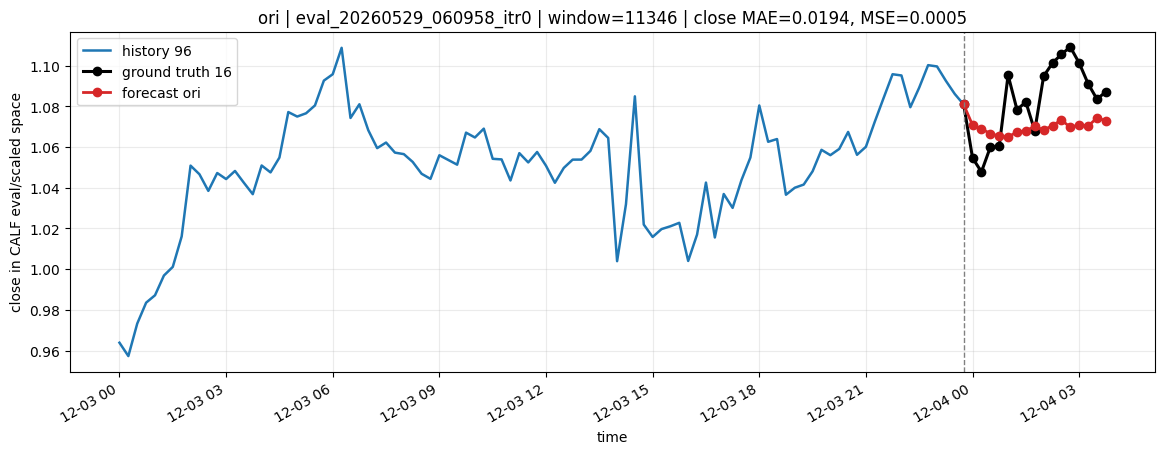

In [38]:
plot_variant("ori", WINDOW_INDEX)

## Ablation: dropAttn_keepWE

This cell plots only the `dropAttn_keepWE` experiment using the same validated window.

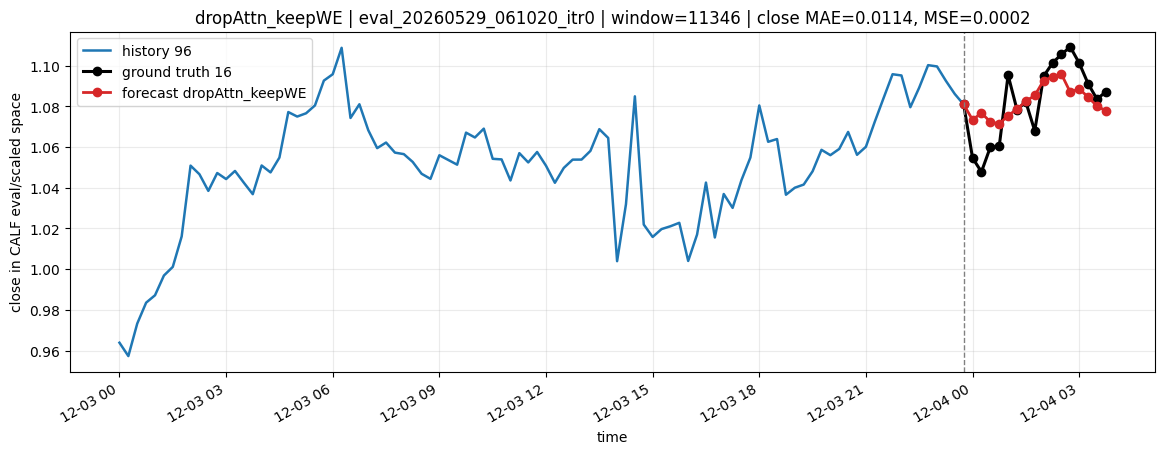

In [39]:
plot_variant("dropAttn_keepWE", WINDOW_INDEX)

## Ablation: llm_to_attn

This cell plots only the `llm_to_attn` experiment using the same validated window.

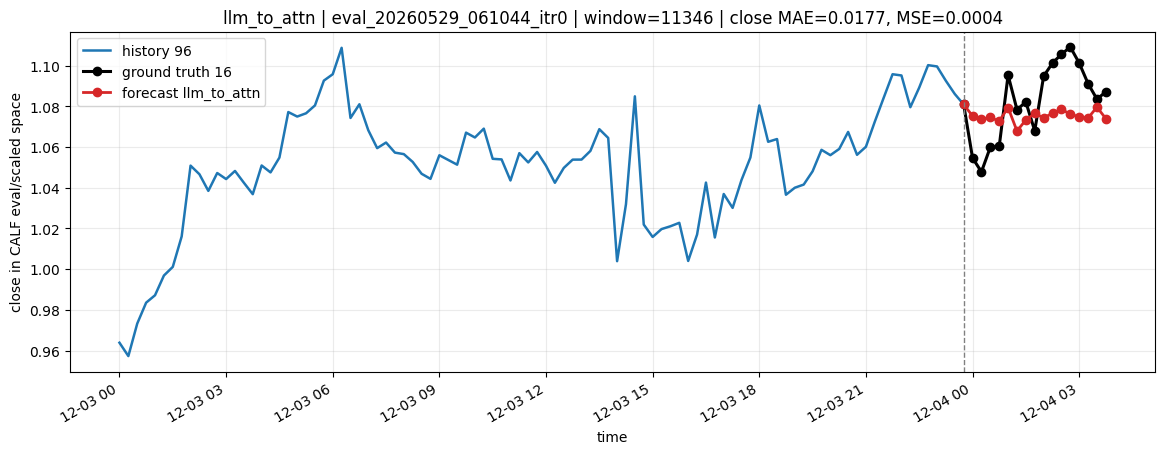

In [40]:
plot_variant("llm_to_attn", WINDOW_INDEX)

## Ablation: llm_to_trsf

This cell plots only the `llm_to_trsf` experiment using the same validated window.

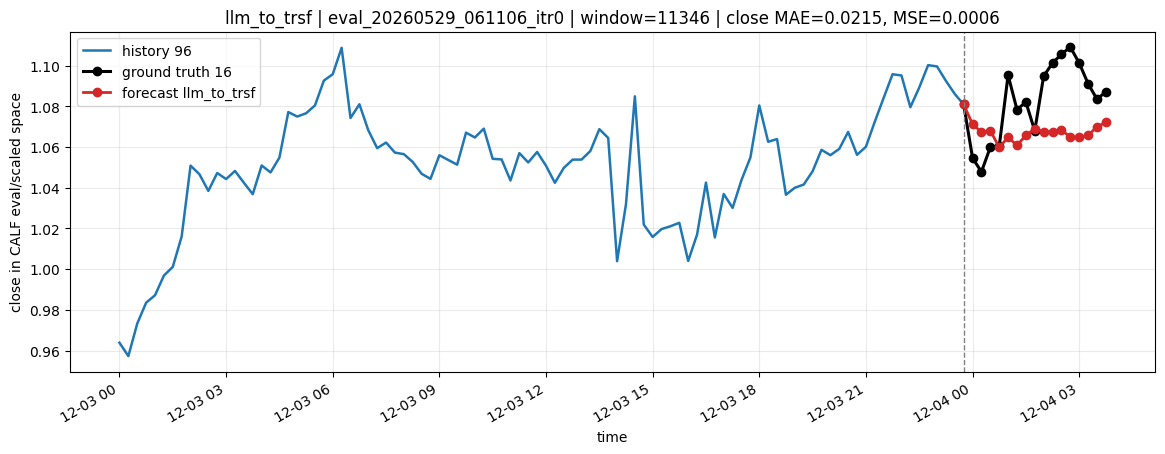

In [41]:
plot_variant("llm_to_trsf", WINDOW_INDEX)

## Compare selected variants on the same window

All forecasts are compared against the same validated ground truth and context window.

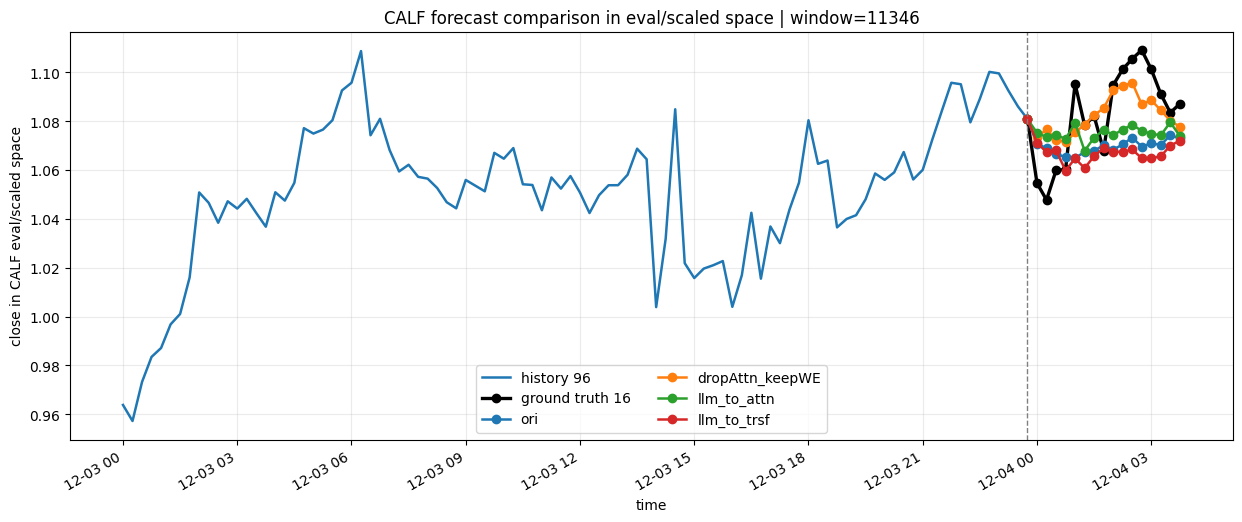

In [42]:
def plot_selected_variants(window_idx: int = WINDOW_INDEX) -> None:
    if selected_artifacts.empty:
        raise RuntimeError("No selected artifacts")

    row0 = selected_artifacts.iloc[0]
    seq_len = int(row0.seq_len)
    pred_len = int(row0.pred_len)
    context_times, future_times = window_times(window_idx, seq_len, pred_len)
    future_with_anchor = pd.concat([context_times.iloc[[-1]], future_times])

    context_close = context_values[window_idx, :, TARGET_INDEX]
    true_close = true_values[window_idx, :, TARGET_INDEX]
    true_line = np.concatenate([[context_close[-1]], true_close])

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(context_times, context_close, color="tab:blue", linewidth=1.8, label=f"history {seq_len}")
    ax.plot(future_with_anchor, true_line, color="black", marker="o", linewidth=2.4, label=f"ground truth {pred_len}")

    for _, row in selected_artifacts.iterrows():
        pred_values = artifact_pred_values(row)
        pred_close = pred_values[window_idx, :, TARGET_INDEX]
        pred_line = np.concatenate([[context_close[-1]], pred_close])
        ax.plot(future_with_anchor, pred_line, marker="o", linewidth=1.8, label=f"{row.variant}")

    ax.axvline(context_times.iloc[-1], color="gray", linestyle="--", linewidth=1.0)
    ax.set_title(f"CALF forecast comparison in eval/scaled space | window={window_idx}")
    ax.set_xlabel("time")
    ax.set_ylabel(f"{TARGET} in CALF eval/scaled space")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2)
    fig.autofmt_xdate()
    plt.show()
    plt.close(fig)

plot_selected_variants(WINDOW_INDEX)

## Window-level error table

This table helps choose additional windows to inspect. Values are MAE on saved evaluation-space `close` over the 16-step horizon.

In [43]:
def close_mae_by_window(row: pd.Series) -> np.ndarray:
    pred_values = artifact_pred_values(row)
    return np.mean(np.abs(pred_values[:, :, TARGET_INDEX] - true_values[:, :, TARGET_INDEX]), axis=1)

error_table = pd.DataFrame({"window_idx": np.arange(len(true_values))})
for _, row in selected_artifacts.iterrows():
    error_table[row.variant] = close_mae_by_window(row)
error_table["mean_selected"] = error_table[[row.variant for _, row in selected_artifacts.iterrows()]].mean(axis=1)
display(error_table.sort_values("mean_selected", ascending=False).head(20))

,window_idx,ori,dropAttn_keepWE,llm_to_attn,llm_to_trsf,mean_selected
6149,6149,0.249296,0.245609,0.225611,0.259932,0.245112
6148,6148,0.234828,0.225077,0.208853,0.248146,0.229226
1418,1418,0.221684,0.224728,0.225880,0.221258,0.223387
6147,6147,0.219293,0.202792,0.191979,0.237471,0.212884
7178,7178,0.207228,0.211928,0.210189,0.207334,0.209170
1417,1417,0.204614,0.208904,0.211453,0.205635,0.207652
1419,1419,0.200238,0.202848,0.205317,0.202153,0.202639
6150,6150,0.215262,0.173716,0.183154,0.233035,0.201292
6146,6146,0.210463,0.180901,0.181505,0.230392,0.200815
1420,1420,0.198378,0.201314,0.202155,0.200919,0.200692
